<a href="https://colab.research.google.com/github/dbright123/Dbot-Advance/blob/main/market_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import MetaTrader5 as mt5
import pandas as pd

def fetch_rates(symbol, timeframe, count=9_000_000):
    """Pull rates from MT5 and return a tidy DataFrame."""
    rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, count)
    
    if rates is None:
        raise ValueError(f"MT5 returned None for {symbol}. Error: {mt5.last_error()}")
    
    df = pd.DataFrame(rates)
    
    # ── Debug: show what columns MT5 actually gave us ──────────────────────
    print(f"Available columns: {list(df.columns)}")
    
    # ── Grab volume column whatever it is called ────────────────────────────
    vol_col = next((c for c in df.columns if "volume" in c.lower()), None)
    if vol_col is None:
        raise KeyError(f"No volume column found among: {list(df.columns)}")
    
    df = df[["time", "open", "high", "low", "close", vol_col]].copy()
    df.rename(columns={vol_col: "volume"}, inplace=True)
    #df["time"] = pd.to_datetime(df["time"], unit="s")
    return df.set_index("time")


def build_multi_tf(symbol):
    if not mt5.initialize(r"C:\Program Files\MetaTrader 5\terminal64.exe"):
        raise RuntimeError(f"MT5 initialize() failed: {mt5.last_error()}")

    df_1h = fetch_rates(symbol, mt5.TIMEFRAME_H1).reset_index()
    df_4h = fetch_rates(symbol, mt5.TIMEFRAME_H4).reset_index()
    df_1d = fetch_rates(symbol, mt5.TIMEFRAME_D1).reset_index()

    def tag_and_shift(df, suffix):
        df = df.sort_values("time").rename(
            columns={c: f"{c}_{suffix}" for c in df.columns if c != "time"})
        val_cols = [c for c in df.columns if c != "time"]
        df[val_cols] = df[val_cols].shift(1)      # <-- only use CLOSED bars
        return df

    df_4h = tag_and_shift(df_4h, "4h")
    df_1d = tag_and_shift(df_1d, "1d")
    df_1h = df_1h.sort_values("time")

    merged = pd.merge_asof(df_1h, df_4h, on="time", direction="backward")
    merged = pd.merge_asof(merged, df_1d, on="time", direction="backward")
    return merged

# ── Run ────────────────────────────────────────────────────────────────────────
symbol = "XAUUSD"
df = build_multi_tf(symbol)

out_path = f"Generated{symbol} dbot.csv"
df.to_csv(out_path, index=False)
print(f"\nSaved {len(df):,} rows → {out_path}")
print(df.head())

Available columns: ['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']
Available columns: ['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']
Available columns: ['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']

Saved 128,365 rows → GeneratedXAUUSD dbot.csv
         time   open   high    low  close  volume  open_4h  high_4h  low_4h  \
0  1086937200  384.0  384.3  383.3  383.8      47      NaN      NaN     NaN   
1  1086940800  383.8  384.3  383.1  383.1      44    384.0    384.3   383.3   
2  1086944400  383.1  384.1  382.8  383.1      57    384.0    384.3   383.3   
3  1086948000  383.0  383.8  383.0  383.6      40    384.0    384.3   383.3   
4  1086951600  383.6  383.8  383.5  383.6      29    384.0    384.3   383.3   

   close_4h  volume_4h  open_1d  high_1d  low_1d  close_1d  volume_1d  
0       NaN        NaN      NaN      NaN     NaN       NaN        NaN  
1     383.8       47.0      NaN   

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import warnings

import joblib
from extra_function import RobustPriceLabelerV3, engineer_features, plot_signals

#warnings.filterwarnings('ignore')

In [7]:


print("="*70)
print("TRADING SIGNAL CLASSIFICATION SYSTEM")
print("="*70)

# Step 1: Load data from Excel
print("\nStep 1: Loading data from Excel file...")
t_symbol = ["XAUUSD","#BTCUSD","GBPUSD","Volatility 100 (1s) Index","Step Index"] #GPBUSD is 1 hour and XAUUSD is 15 min data
n = 0
m_label = "Generated"+t_symbol[n]






TRADING SIGNAL CLASSIFICATION SYSTEM

Step 1: Loading data from Excel file...


In [8]:
import numpy as np, pandas as pd

def _atr_series(df, n=14):
    pc = df['close'].shift(1)
    tr = pd.concat([df['high']-df['low'], (df['high']-pc).abs(), (df['low']-pc).abs()],
                   axis=1).max(axis=1)
    return tr.ewm(alpha=1/n, adjust=False).mean()

def engineer_features_stationary(df):
    """Keeps ALL raw columns (backtest/CSV need them) and ADDS price-level-invariant
       features. TIER A = snapshot-computable live. TIER B = needs history buffer."""
    df = df.copy()
    # ---- time ----
    df['time'] = pd.to_datetime(df['time'], unit='s', errors='coerce')
    df['month']=df['time'].dt.month; df['day']=df['time'].dt.day
    df['hour']=df['time'].dt.hour;   df['day_of_week']=df['time'].dt.dayofweek
    df['hour_sin']=np.sin(2*np.pi*df['hour']/24); df['hour_cos']=np.cos(2*np.pi*df['hour']/24)
    df['dow_sin'] =np.sin(2*np.pi*df['day_of_week']/7); df['dow_cos']=np.cos(2*np.pi*df['day_of_week']/7)

    rng   = (df['high']-df['low']).replace(0,np.nan)
    rng4  = (df['high_4h']-df['low_4h']).replace(0,np.nan)
    rng1d = (df['high_1d']-df['low_1d']).replace(0,np.nan)

    # ===== TIER A : snapshot-only (LIVE-SAFE, no EA/server change) =====
    df['pos_in_bar']=(df['close']-df['low'])/rng
    df['body_ratio']=(df['close']-df['open'])/rng
    df['wick_up']=(df['high']-df[['open','close']].max(axis=1))/rng
    df['wick_dn']=(df[['open','close']].min(axis=1)-df['low'])/rng
    df['vs_4h']=df['close']/df['close_4h']-1
    df['vs_1d']=df['close']/df['close_1d']-1
    df['pos_4h']=(df['close']-df['low_4h'])/rng4
    df['pos_1d']=(df['close']-df['low_1d'])/rng1d
    df['range_rel']=rng/rng1d
    df['gap_open']=(df['open']-df['close_4h'])/df['close_4h']

    # ===== TIER B : needs bar history (server must buffer to use these) =====
    atr=_atr_series(df,14)
    df['ret_1']=df['close'].pct_change(1)
    df['ret_3']=df['close'].pct_change(3)
    df['ret_6']=df['close'].pct_change(6)
    df['body_atr']=(df['close']-df['open'])/atr
    df['atr_pct']=atr/df['close']
    vmu=df['volume'].rolling(20,min_periods=5).mean()
    vsd=df['volume'].rolling(20,min_periods=5).std().replace(0,np.nan)
    df['vol_z']=(df['volume']-vmu)/vsd

    df=df.drop(columns=['time'])
    return df.replace([np.inf,-np.inf],np.nan).dropna().reset_index(drop=True)

df = engineer_features_stationary(df)
print(df.shape)

(128114, 39)


In [9]:
df 

,open,high,low,close,volume,open_4h,high_4h,low_4h,close_4h,volume_4h,...,pos_4h,pos_1d,range_rel,gap_open,ret_1,ret_3,ret_6,body_atr,atr_pct,vol_z
0,384.30,384.50,383.60,383.60,16,384.30,384.80,383.80,384.10,29.0,...,-0.200000,0.400000,0.450000,0.000521,-0.001302,-0.001821,-0.001042,-0.838590,0.002176,-0.477736
1,384.30,384.30,382.30,383.00,63,384.30,384.80,383.80,384.10,29.0,...,-0.800000,0.100000,1.000000,0.000521,-0.001564,-0.002084,-0.002084,-1.416172,0.002397,1.784538
2,382.80,383.30,382.30,382.60,56,384.30,384.80,383.80,384.10,29.0,...,-1.200000,-0.100000,0.500000,-0.003385,-0.001044,-0.003905,-0.005200,-0.216491,0.002415,1.297116
3,382.60,383.30,382.60,383.00,46,384.30,384.50,382.30,382.60,135.0,...,0.318182,0.100000,0.350000,0.000000,0.001045,-0.001564,-0.003383,0.440607,0.002370,0.772145
4,382.80,383.30,382.80,383.00,17,384.30,384.50,382.30,382.60,135.0,...,0.318182,0.100000,0.250000,0.000523,0.000000,0.000000,-0.002084,0.227607,0.002294,-0.623226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128109,4154.28,4155.63,4135.78,4139.06,24323,4125.99,4175.14,4119.80,4172.27,73942.0,...,0.348030,0.142378,0.266121,-0.004312,-0.003664,-0.007960,0.001883,-0.916244,0.004013,0.966571
128110,4139.06,4147.26,4137.01,4145.11,19210,4125.99,4175.14,4119.80,4172.27,73942.0,...,0.457355,0.223488,0.137418,-0.007960,0.001462,-0.003208,0.002273,0.374453,0.003898,0.158590
128111,4145.11,4148.20,4140.62,4144.55,16345,4172.27,4180.51,4135.78,4145.11,106022.0,...,0.196065,0.215981,0.101622,0.000000,-0.000135,-0.002342,-0.002945,-0.036026,0.003751,-0.297005
128112,4144.58,4145.27,4125.09,4127.05,18815,4172.27,4180.51,4135.78,4145.11,106022.0,...,-0.195171,-0.018635,0.270546,-0.000128,-0.004222,-0.002902,-0.010838,-1.104224,0.003847,-0.019652


In [10]:
labeler = RobustPriceLabelerV3(atr_period=14, zigzag_atr_mult=0.5,
                               hold_bars=1, min_streak=0.01, target_hold_pct=0.01)

# label train and test SEPARATELY so the zigzag never sees across the split
df_train = labeler.label(df.iloc[:-1000].copy()).reset_index(drop=True)
df_test  = labeler.label(df.iloc[-1000:].copy()).reset_index(drop=True)
df = df_train
print("train:", df.shape, "| test:", df_test.shape)
print(df[["close","label","label_name","label_conf"]].tail())

Computing ATR...
Finding zigzag pivots...
   56030 pivots found
Assigning zone labels...
Enforcing class balance...
Computing confidence scores...

── Label Distribution ──────────────────────────
  buy : 43,208  ( 34.0%)  █████████████
  sell: 40,445  ( 31.8%)  ████████████
  hold: 43,461  ( 34.2%)  █████████████
────────────────────────────────────────────────
Computing ATR...
Finding zigzag pivots...
   442 pivots found
Assigning zone labels...
Enforcing class balance...
Computing confidence scores...

── Label Distribution ──────────────────────────
  buy :    261  ( 26.1%)  ██████████
  sell:    396  ( 39.6%)  ███████████████
  hold:    343  ( 34.3%)  █████████████
────────────────────────────────────────────────
train: (127114, 42) | test: (1000, 42)
          close  label label_name  label_conf
127109  4530.03      0       hold       0.279
127110  4540.89      0       hold       0.292
127111  4539.04      0       hold       0.297
127112  4534.56      0       hold       0.361
127

In [11]:


"""Analyze the labeling results"""
print(f"Total samples: {len(df)}")
print(f"Buy labels: {(df['label'] == 1).sum()} ({((df['label'] == 1).sum()/len(df))*100:.1f}%)")
print(f"Sell labels: {(df['label'] == 2).sum()} ({((df['label'] == 2).sum()/len(df))*100:.1f}%)")
print(f"Hold labels: {(df['label'] == 0).sum()} ({((df['label'] == 0).sum()/len(df))*100:.1f}%)")



Total samples: 127114
Buy labels: 43208 (34.0%)
Sell labels: 40445 (31.8%)
Hold labels: 43461 (34.2%)



Step 5: Visualizing trading signals...


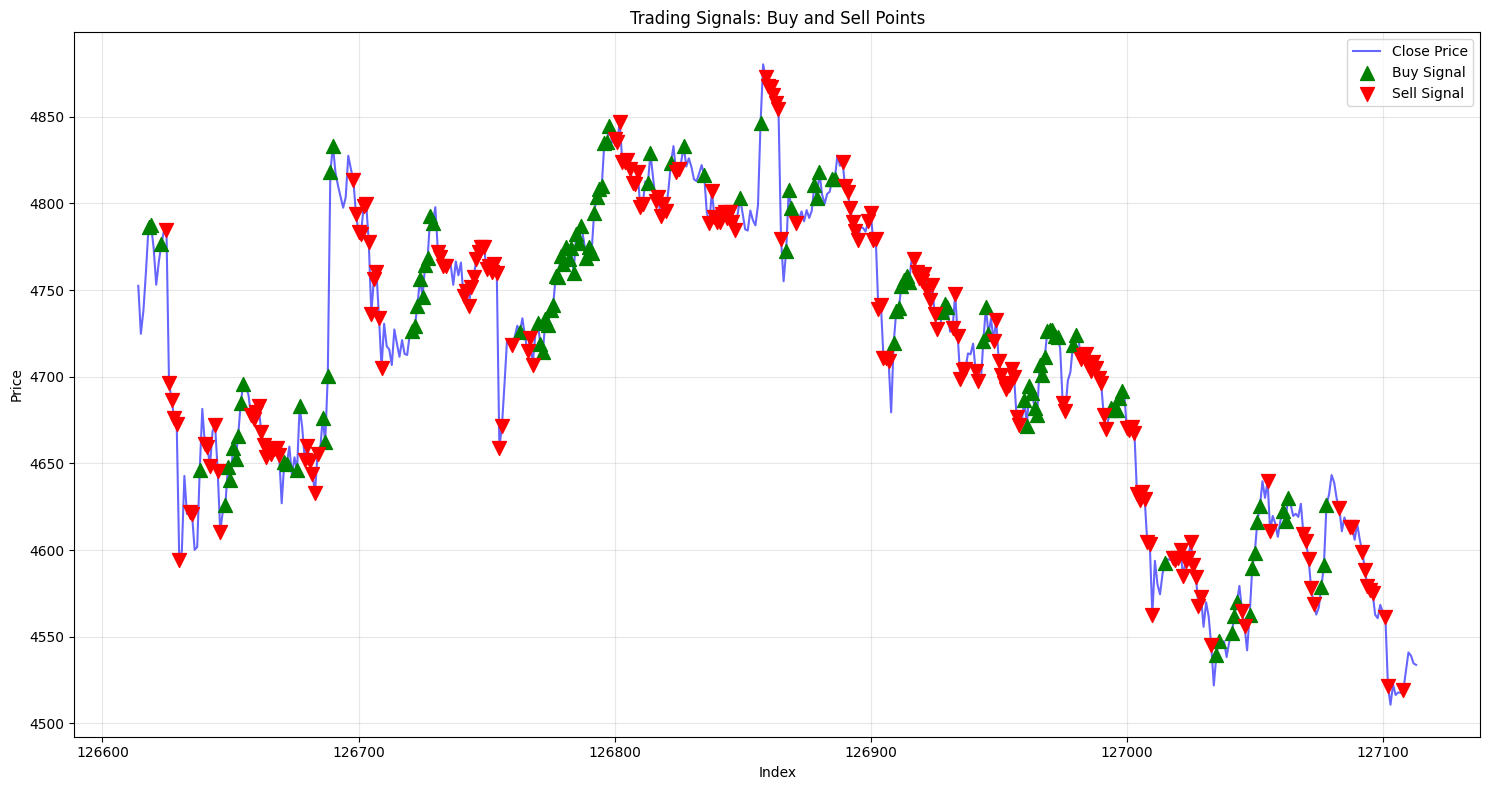


Signal Distribution:
Hold/No Action (0): 167
Buy Signals (1): 125
Sell Signals (2): 208


In [12]:

# Step 5: Visualize signals
print("\nStep 5: Visualizing trading signals...")
plot_signals(df[-500:])



In [13]:
print(f"Data loaded: {len(df)} rows")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Data loaded: 127114 rows
Memory usage: 44.69 MB


In [14]:
df

,open,high,low,close,volume,open_4h,high_4h,low_4h,close_4h,volume_4h,...,gap_open,ret_1,ret_3,ret_6,body_atr,atr_pct,vol_z,label,label_name,label_conf
0,384.30,384.50,383.60,383.60,16,384.30,384.80,383.80,384.10,29.0,...,0.000521,-0.001302,-0.001821,-0.001042,-0.838590,0.002176,-0.477736,2,sell,0.566
1,384.30,384.30,382.30,383.00,63,384.30,384.80,383.80,384.10,29.0,...,0.000521,-0.001564,-0.002084,-0.002084,-1.416172,0.002397,1.784538,2,sell,0.528
2,382.80,383.30,382.30,382.60,56,384.30,384.80,383.80,384.10,29.0,...,-0.003385,-0.001044,-0.003905,-0.005200,-0.216491,0.002415,1.297116,2,sell,0.392
3,382.60,383.30,382.60,383.00,46,384.30,384.50,382.30,382.60,135.0,...,0.000000,0.001045,-0.001564,-0.003383,0.440607,0.002370,0.772145,2,sell,0.332
4,382.80,383.30,382.80,383.00,17,384.30,384.50,382.30,382.60,135.0,...,0.000523,0.000000,0.000000,-0.002084,0.227607,0.002294,-0.623226,0,hold,0.242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127109,4519.01,4530.50,4513.60,4530.03,14521,4510.72,4531.68,4509.85,4517.81,60511.0,...,0.000266,0.002439,0.002705,0.004281,0.560743,0.004338,-0.615333,0,hold,0.279
127110,4529.91,4542.09,4525.46,4540.89,15819,4523.49,4530.50,4513.60,4530.03,25458.0,...,-0.000026,0.002397,0.005171,0.004086,0.564914,0.004280,-0.462338,0,hold,0.292
127111,4540.89,4546.69,4534.64,4539.04,11972,4523.49,4530.50,4513.60,4530.03,25458.0,...,0.002397,-0.000407,0.004432,0.005028,-0.097837,0.004166,-0.927632,0,hold,0.297
127112,4539.04,4542.73,4532.34,4534.56,9418,4523.49,4530.50,4513.60,4530.03,25458.0,...,0.001989,-0.000987,0.001000,0.003708,-0.244802,0.004036,-1.154652,0,hold,0.361


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

FEATURES_A = ['pos_in_bar','body_ratio','wick_up','wick_dn','vs_4h','vs_1d',
              'pos_4h','pos_1d','range_rel','gap_open',
              'hour_sin','hour_cos','dow_sin','dow_cos']
FEATURES_B = FEATURES_A + ['ret_1','ret_3','ret_6','body_atr','atr_pct','vol_z']

def walk_forward(df, feats, train_bars=10000, test_bars=250, step=5000):
    accs, base = [], []
    for s in range(train_bars, len(df)-test_bars, step):
        tr, te = df.iloc[s-train_bars:s], df.iloc[s:s+test_bars]
        m = RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                   class_weight='balanced', random_state=42)
        m.fit(tr[feats].values, tr['label'].values)
        acc = accuracy_score(te['label'].values, m.predict(te[feats].values))
        maj = te['label'].value_counts(normalize=True).max()   # baseline
        accs.append(acc); base.append(maj)
        print(f"fold @{s:6d}  acc={acc:.3f}  (baseline {maj:.3f}  edge {acc-maj:+.3f})")
    print(f"\nmean acc {np.mean(accs):.3f} ± {np.std(accs):.3f} | "
          f"mean baseline {np.mean(base):.3f} | EDGE {np.mean(accs)-np.mean(base):+.3f}")
    return np.mean(accs)-np.mean(base)

print("===== TIER A (live-safe) ====="); ea = walk_forward(df, FEATURES_A)
print("\n===== TIER B (needs history) ====="); eb = walk_forward(df, FEATURES_B)
print(f"\nEdge A={ea:+.3f}  B={eb:+.3f}  -> pick the one with a POSITIVE, STABLE edge")

===== TIER A (live-safe) =====
fold @ 10000  acc=0.560  (baseline 0.464  edge +0.096)
fold @ 15000  acc=0.484  (baseline 0.384  edge +0.100)
fold @ 20000  acc=0.568  (baseline 0.360  edge +0.208)
fold @ 25000  acc=0.508  (baseline 0.352  edge +0.156)
fold @ 30000  acc=0.512  (baseline 0.416  edge +0.096)
fold @ 35000  acc=0.484  (baseline 0.388  edge +0.096)
fold @ 40000  acc=0.560  (baseline 0.392  edge +0.168)
fold @ 45000  acc=0.464  (baseline 0.448  edge +0.016)
fold @ 50000  acc=0.476  (baseline 0.384  edge +0.092)
fold @ 55000  acc=0.500  (baseline 0.532  edge -0.032)
fold @ 60000  acc=0.508  (baseline 0.408  edge +0.100)
fold @ 65000  acc=0.532  (baseline 0.376  edge +0.156)
fold @ 70000  acc=0.512  (baseline 0.360  edge +0.152)
fold @ 75000  acc=0.536  (baseline 0.416  edge +0.120)
fold @ 80000  acc=0.584  (baseline 0.356  edge +0.228)
fold @ 85000  acc=0.560  (baseline 0.388  edge +0.172)
fold @ 90000  acc=0.488  (baseline 0.356  edge +0.132)
fold @ 95000  acc=0.444  (baseline

In [17]:
import joblib
from sklearn.metrics import classification_report, confusion_matrix

FEATURES = FEATURES_A          # switch to FEATURES_B ONLY if Cell 3 shows it's clearly better
                               # AND your server can buffer history

model = RandomForestClassifier(n_estimators=400, n_jobs=-1,
                               class_weight='balanced', random_state=42, verbose=1)
model.fit(df[FEATURES].values, df['label'].values)     # train on ALL training rows

# ---- honest hold-out check (this replaces the fake shuffled 94%) ----
df_test['predicted_label'] = model.predict(df_test[FEATURES].values)
print("HOLD-OUT accuracy:", accuracy_score(df_test['label'], df_test['predicted_label']))
print(confusion_matrix(df_test['label'], df_test['predicted_label']))
print(classification_report(df_test['label'], df_test['predicted_label']))

# ---- export EVERYTHING the backtest simulator needs ----
export_cols = ['open','high','low','close','volume',
               'open_4h','high_4h','low_4h','close_4h','volume_4h',
               'open_1d','high_1d','low_1d','close_1d','volume_1d',
               'month','day','hour','day_of_week',
               'label','label_name','label_conf','predicted_label']
df_test[export_cols].to_csv('test_predictions.csv', index=False)
joblib.dump({'model':model,'features':FEATURES}, 'model_bundle.pkl')
print(f"exported {len(df_test)} rows, {len(export_cols)} cols | saved model_bundle.pkl")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   17.3s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:  2.6min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 400 out of 400 | elapsed:    0.2s finished


HOLD-OUT accuracy: 0.542
[[104 105 134]
 [ 46 187  28]
 [101  44 251]]
              precision    recall  f1-score   support

           0       0.41      0.30      0.35       343
           1       0.56      0.72      0.63       261
           2       0.61      0.63      0.62       396

    accuracy                           0.54      1000
   macro avg       0.53      0.55      0.53      1000
weighted avg       0.53      0.54      0.53      1000

exported 1000 rows, 23 cols | saved model_bundle.pkl


In [18]:
import pandas as pd
import mplfinance as mpf
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def predict_and_plot_signals(model, df, feature_columns,
                             ohlc_map=None,
                             chart_style='charles'):
    """
    Predicts buy/sell signals and plots them on an OHLC candlestick chart.

    Parameters
    ----------
    model : trained classifier with a `predict` method
    df : pandas.DataFrame
        Must contain OHLC columns (default names: 'open','high','low','close')
        and all columns listed in feature_columns.
    feature_columns : list of str
        Columns used as features for the model.
    ohlc_map : dict, optional
        Maps standard OHLC names to actual df column names.
        Default: {'Open':'open','High':'high','Low':'low','Close':'close'}
    chart_style : str, default 'charles'
        mplfinance style (e.g., 'charles', 'yahoo', 'binance', 'default').
    """
    # --- 0. Work on a copy to avoid side effects ---
    data = df.copy()

    # --- 1. Ensure DatetimeIndex ---
    if not pd.api.types.is_datetime64_any_dtype(data.index):
        try:
            data.index = pd.to_datetime(data.index)
        except Exception as e:
            raise ValueError("Could not convert DataFrame index to DatetimeIndex. "
                             "Please provide a DataFrame with a datetime-like index.") from e

    # --- 2. Map OHLC columns ---
    if ohlc_map is None:
        ohlc_map = {'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close'}

    for col in ohlc_map.values():
        if col not in data.columns:
            raise KeyError(f"Required OHLC column '{col}' not found in DataFrame.")

    ohlc_df = data[[ohlc_map['Open'], ohlc_map['High'],
                    ohlc_map['Low'], ohlc_map['Close']]].copy()
    ohlc_df.columns = ['Open', 'High', 'Low', 'Close']
    # Keep the (now datetime) index from data

    # --- 3. Make predictions ---
    X = data[feature_columns].values
    data['predicted_label'] = model.predict(X)

    # --- 4. Build marker Series with the SAME index as ohlc_df ---
    buy_marker = pd.Series(index=ohlc_df.index, dtype=float, name='buy')
    sell_marker = pd.Series(index=ohlc_df.index, dtype=float, name='sell')

    buys = data[data['predicted_label'] == 1]
    if not buys.empty:
        buy_marker.loc[buys.index] = buys[ohlc_map['Low']]

    sells = data[data['predicted_label'] == 2]
    if not sells.empty:
        sell_marker.loc[sells.index] = sells[ohlc_map['High']]

    # --- 5. Create addplots ---
    apds = []
    if not buys.empty:
        apds.append(mpf.make_addplot(buy_marker, type='scatter', marker='^',
                                     color='green', markersize=100))
    if not sells.empty:
        apds.append(mpf.make_addplot(sell_marker, type='scatter', marker='v',
                                     color='red', markersize=100))

    # --- 6. Plot ---
    fig, axlist = mpf.plot(ohlc_df,
                           type='candle',
                           style=chart_style,
                           title='Market Predictions: Buy/Sell Signals on Candlestick Chart',
                           ylabel='Price',
                           addplot=apds if apds else None,
                           returnfig=True,
                           figsize=(16, 8),
                           volume=False,
                           warn_too_much_data=len(data) + 50)

    # --- 7. Legend (mplfinance doesn't auto-add for addplots) ---
    legend_elements = [
        Line2D([0], [0], marker='^', color='w', markerfacecolor='green',
               markersize=12, label='Predicted BUY'),
        Line2D([0], [0], marker='v', color='w', markerfacecolor='red',
               markersize=12, label='Predicted SELL')
    ]
    axlist[0].legend(handles=legend_elements, loc='best')
    plt.tight_layout()
    plt.show()

    # --- 8. Print distribution ---
    print("\nSignal Distribution:")
    print(f"Hold / No Action (0): {len(data[data['predicted_label'] == 0])}")
    print(f"Buy Signals      (1): {len(data[data['predicted_label'] == 1])}")
    print(f"Sell Signals     (2): {len(data[data['predicted_label'] == 2])}")

In [19]:

# --- Example Usage ---
# Ensure your 'df' has gone through engineer_features() first
# features = ['open', 'high', 'low', 'volume', 'month', 'day', 'hour', 'minute', 'day_of_week']
#ohlc_map = {'Open':'Open', 'High':'High', 'Low':'Low', 'Close':'Close'}
predict_and_plot_signals(model, df_test[-150:], feature_cols)

NameError: name 'feature_cols' is not defined

════════════════════════════════════════════════════════════════════════════
DATA OVERVIEW
════════════════════════════════════════════════════════════════════════════
bars 1000 | gold 3963-4767 | median ATR 19.8 pts  | 05/05 07:00 -> 07/07 21:00
net move over window: -393.4 pts (-8.68%)
label           : hold=343 buy=262 sell=395
predicted_label : hold=375 buy=341 sell=284

════════════════════════════════════════════════════════════════════════════
MODEL PERFORMANCE (label vs predicted_label)
════════════════════════════════════════════════════════════════════════════
accuracy: 39.70%  (397/1000)
pred    buy  hold  sell
actual                 
buy     113    83    66
hold    107   151    85
sell    121   141   133
  hold  precision=0.403 recall=0.440 support=343
  buy   precision=0.331 recall=0.431 support=262
  sell  precision=0.468 recall=0.337 support=395
label_conf | correct=0.512  incorrect=0.510  (NOT a usable filter)

═══════════════════════════════════════════════════════════

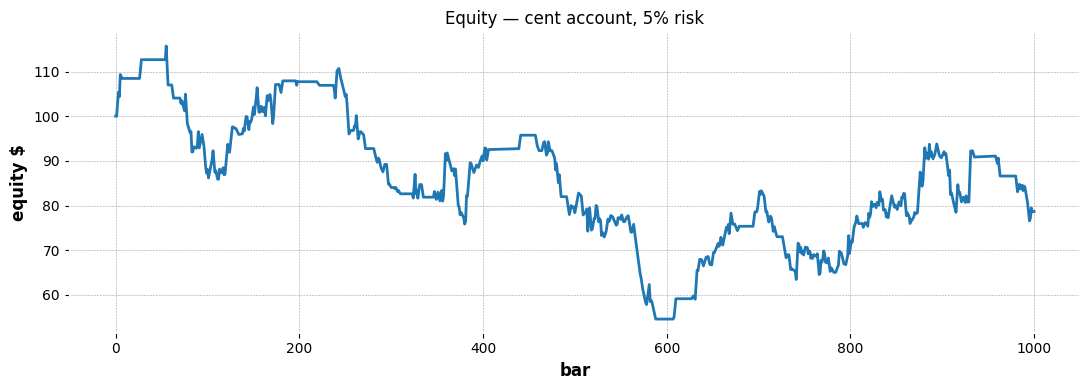

In [ ]:
"""
════════════════════════════════════════════════════════════════════════════
 XAUUSD $100 STRATEGY SIMULATOR — full diagnostics build
 Single position, decision at bar close -> fill next bar open.
 Intrabar worst-case: SL checked before TP. Trades ONLY on predicted_label
 (label_conf proven inverted & not available live). Cent vs standard account,
 dynamic risk-based lot sizing, broker margin-call enforcement.
════════════════════════════════════════════════════════════════════════════
"""
import numpy as np
import pandas as pd

# ────────────────────────────── CONFIG ────────────────────────────────────
CSV = r"e:\GitHub\Dbot-Advance\test_predictions.csv"

ACCOUNT      = "cent"     # "cent" (needed for $100 gold) | "standard"
VALUE        = 1.0 if ACCOUNT == "cent" else 100.0   # USD per $1 move per 1.0 lot
MIN_LOT, LOT_STEP, MAX_LOT = 0.01, 0.01, 100.0
START_EQUITY = 100.0
LEVERAGE     = 500
STOPOUT_LVL  = 20.0       # margin level % -> liquidation
SPREAD       = 0.30       # gold spread ($) — set to your broker's average

RISK_FRAC       = 0.05    # risk per trade (fraction of equity)
SL_ATR, TP_ATR  = 1.5, 3.0
ATR_LEN, ADX_LEN = 14, 14
SESSION_HOURS   = set(range(13, 21))   # US session — tune to broker server time
ADX_MIN, MIN_VOL, PERSIST_N = 20.0, 500, 2
LABEL_MAP = {0: "hold", 1: "buy", 2: "sell"}

# feature toggles (trading mechanics)
BASE = dict(flip_cut=True, exit_hold=True, session=False, htf_align=False,
            adx=False, persist=False, volume=False, partial=False, dyn_size=True)


# ────────────────────────────── INDICATORS ────────────────────────────────
def wilder(s, n): return s.ewm(alpha=1/n, adjust=False).mean()

def indicators(df):
    h, l, c = df.high, df.low, df.close; pc = c.shift(1)
    tr  = pd.concat([h-l, (h-pc).abs(), (l-pc).abs()], axis=1).max(axis=1)
    atr = wilder(tr, ATR_LEN)
    up, dn = h.diff(), -l.diff()
    plus  = pd.Series(np.where((up > dn) & (up > 0), up, 0.0), df.index)
    minus = pd.Series(np.where((dn > up) & (dn > 0), dn, 0.0), df.index)
    atr_a = wilder(tr, ADX_LEN)
    pdi = 100*wilder(plus,  ADX_LEN)/atr_a
    mdi = 100*wilder(minus, ADX_LEN)/atr_a
    dx  = 100*(pdi-mdi).abs()/(pdi+mdi).replace(0, np.nan)
    adx = wilder(dx.fillna(0), ADX_LEN)
    return atr.values, adx.values


# ───────────────────────── DIAGNOSTIC REPORTS ─────────────────────────────
def data_overview(df):
    atr, _ = indicators(df)
    print("═"*76)
    print(f"DATA OVERVIEW")
    print("═"*76)
    span = ""
    if {"month","day","hour"}.issubset(df.columns):
        a, b = df.iloc[0], df.iloc[-1]
        span = (f"  | {int(a.month):02d}/{int(a.day):02d} {int(a.hour):02d}:00"
                f" -> {int(b.month):02d}/{int(b.day):02d} {int(b.hour):02d}:00")
    print(f"bars {len(df)} | gold {df.close.min():.0f}-{df.close.max():.0f}"
          f" | median ATR {np.nanmedian(atr[ATR_LEN:]):.1f} pts{span}")
    print(f"net move over window: {df.close.iloc[-1]-df.close.iloc[0]:+.1f} pts "
          f"({df.close.iloc[-1]/df.close.iloc[0]-1:+.2%})")
    for col in ("label", "predicted_label"):
        if col in df:
            vc = df[col].map(LABEL_MAP).value_counts()
            print(f"{col:16}: " + " ".join(f"{k}={vc.get(k,0)}" for k in ("hold","buy","sell")))


def model_performance(df):
    if "label" not in df: return
    print("\n" + "═"*76); print("MODEL PERFORMANCE (label vs predicted_label)"); print("═"*76)
    acc = (df.label == df.predicted_label).mean()
    print(f"accuracy: {acc:.2%}  ({int(acc*len(df))}/{len(df)})")
    cm = pd.crosstab(df.label.map(LABEL_MAP), df.predicted_label.map(LABEL_MAP),
                     rownames=["actual"], colnames=["pred"], dropna=False)
    print(cm)
    for cls in (0,1,2):
        tp = ((df.label==cls)&(df.predicted_label==cls)).sum()
        fp = ((df.label!=cls)&(df.predicted_label==cls)).sum()
        fn = ((df.label==cls)&(df.predicted_label!=cls)).sum()
        prec = tp/(tp+fp) if tp+fp else 0; rec = tp/(tp+fn) if tp+fn else 0
        print(f"  {LABEL_MAP[cls]:<5} precision={prec:.3f} recall={rec:.3f} "
              f"support={(df.label==cls).sum()}")
    if "label_conf" in df:
        ok = df.label == df.predicted_label
        print(f"label_conf | correct={df.loc[ok,'label_conf'].mean():.3f}  "
              f"incorrect={df.loc[~ok,'label_conf'].mean():.3f}  "
              f"({'USABLE' if df.loc[ok,'label_conf'].mean() > df.loc[~ok,'label_conf'].mean()+0.03 else 'NOT a usable filter'})")


def leak_checks(df):
    print("\n" + "═"*76); print("LOOKAHEAD LEAK CHECKS (want NON-zero counts)"); print("═"*76)
    r = dict(day_hi=(df.high>df.high_1d).sum(), day_lo=(df.low<df.low_1d).sum(),
             h4_hi=(df.high>df.high_4h).sum(),  h4_lo=(df.low<df.low_4h).sum())
    print(f"bars breaking prior-DAY high/low: {r['day_hi']} / {r['day_lo']}")
    print(f"bars breaking prior-4H  high/low: {r['h4_hi']} / {r['h4_lo']}")
    print("verdict:", "LEAK-FREE" if min(r.values())>0 else "LEAK SUSPECTED")


def label_diagnostic(df):
    if "label" not in df: return
    print("\n" + "═"*76); print("LABEL DIAGNOSTIC — forward predictor vs regime classifier"); print("═"*76)
    d = df.copy()
    for hh in (1,3,6): d[f"fwd{hh}"] = d.close.shift(-hh)/d.close - 1
    d["mom3"] = d.close/d.close.shift(3) - 1
    d["vs1d"] = d.close/d.close_1d - 1
    g = d.groupby(d.label.map(LABEL_MAP))
    print("FORWARD returns by label (does label predict the future?):")
    print((g[["fwd1","fwd3","fwd6"]].mean()*100).round(3).astype(str)+" %")
    buy, sell = d[d.label==1], d[d.label==2]
    print(f"  P(fwd3>0|buy)={ (buy.fwd3>0).mean():.1%}   P(fwd3<0|sell)={(sell.fwd3<0).mean():.1%}")
    print("PAST context by label (is label just current regime?):")
    print((g[["mom3","vs1d"]].mean()*100).round(3).astype(str)+" %")
    fwd_gap  = abs(buy.fwd3.mean() - sell.fwd3.mean())
    past_gap = abs(buy.mom3.mean() - sell.mom3.mean())
    print(f"buy-vs-sell separation: forward={fwd_gap*100:.3f}%  past={past_gap*100:.3f}%")
    if fwd_gap > past_gap and buy.fwd3.mean() > 0 > sell.fwd3.mean():
        print("  => FORWARD-PREDICTIVE (trade signals directly).")
    else:
        print("  => TREND/REGIME CLASSIFIER (trade only WITH the trend; weak as standalone signal).")


# ────────────────────────────── SIZING ────────────────────────────────────
def size_lot(equity, sl_dist, cfg):
    if not cfg["dyn_size"]:
        lot = MIN_LOT
    else:
        raw = (RISK_FRAC*equity)/(sl_dist*VALUE)
        lot = min(max(np.floor(raw/LOT_STEP)*LOT_STEP, MIN_LOT), MAX_LOT)
    risk = lot*sl_dist*VALUE
    forced = risk > RISK_FRAC*equity*1.5
    return round(lot, 2), risk, forced


# ────────────────────────────── SIMULATOR ─────────────────────────────────
def simulate(df, cfg):
    atr, adx = indicators(df)
    d = df.reset_index(drop=True)
    O,H,L,C,V = (d[k].values for k in ["open","high","low","close","volume"])
    HR  = d["hour"].values  if "hour"  in d else np.zeros(len(d))
    MON = d["month"].values if "month" in d else np.zeros(len(d))
    C1D = d["close_1d"].values
    sig_arr = d.predicted_label.map({0:0,1:1,2:-1}).values
    n = len(d)

    realized = 0.0; equity = START_EQUITY
    pos = None; pending = None
    trades = []; eq = [equity]; lots = []; liq = 0; forced_ct = 0

    def emit(pos, exit_px, final_lot, reason):
        nonlocal realized, equity
        final_pnl = pos["dir"]*(exit_px-pos["entry"])*final_lot*VALUE
        total = pos["partial_pnl"] + final_pnl
        realized += total; equity = START_EQUITY+realized
        rdist = pos["rdist"]
        if pos["dir"]>0:
            mae = (pos["entry"]-pos["min_l"])/rdist; mfe = (pos["max_h"]-pos["entry"])/rdist
        else:
            mae = (pos["max_h"]-pos["entry"])/rdist; mfe = (pos["entry"]-pos["min_l"])/rdist
        trades.append(dict(dir=pos["dir"], entry=pos["entry"], exit=exit_px,
                           lot0=pos["lot0"], pnl=total, R=total/pos["risk0"] if pos["risk0"] else 0,
                           reason=reason, bars=pos["bars"], hour=pos["hour"], month=pos["month"],
                           mae_R=mae, mfe_R=mfe))

    for t in range(n):
        a = atr[t]
        # 1) fill pending entry at open
        if pending is not None:
            pdir, lot, risk0, rdist, e_hour, e_mon = pending; pending = None
            e = O[t] + (SPREAD if pdir>0 else 0.0)
            pos = dict(dir=pdir, lot=lot, lot0=lot, entry=e, risk0=risk0, rdist=rdist,
                       sl=e-pdir*SL_ATR*a, tp=e+pdir*TP_ATR*a, scaled=False,
                       bars=0, hour=e_hour, month=e_mon, partial_pnl=0.0,
                       min_l=e, max_h=e)
        # 2) manage open position
        if pos is not None:
            pos["bars"]+=1; pos["min_l"]=min(pos["min_l"],L[t]); pos["max_h"]=max(pos["max_h"],H[t])
            pd_, e = pos["dir"], pos["entry"]
            hit_sl = (L[t]<=pos["sl"]) if pd_>0 else (H[t]>=pos["sl"])
            if hit_sl:
                emit(pos, pos["sl"], pos["lot"], "stop"); pos=None
            else:
                if cfg["partial"] and not pos["scaled"]:
                    oneR = e + pd_*pos["rdist"]
                    if (H[t]>=oneR) if pd_>0 else (L[t]<=oneR):
                        half = round(pos["lot"]/2, 2)
                        if half>=MIN_LOT:
                            pos["partial_pnl"] += pd_*(oneR-e)*half*VALUE
                            pos["lot"] = round(pos["lot"]-half, 2)
                        pos["sl"]=e; pos["scaled"]=True
                if pos is not None:
                    hit_tp = (H[t]>=pos["tp"]) if pd_>0 else (L[t]<=pos["tp"])
                    if hit_tp: emit(pos, pos["tp"], pos["lot"], "target"); pos=None
        # 3) act on signal (fill next open)
        if t < n-1:
            sig = sig_arr[t]
            if pos is not None:
                if sig==0 and cfg["exit_hold"]:
                    emit(pos, C[t], pos["lot"], "hold"); pos=None
                elif sig==-pos["dir"] and cfg["flip_cut"]:
                    emit(pos, C[t], pos["lot"], "flip"); pos=None
            if pos is None and pending is None and sig!=0 and np.isfinite(a):
                ok = True
                if cfg["session"]   and HR[t] not in SESSION_HOURS: ok=False
                if cfg["htf_align"] and not ((C[t]>C1D[t]) if sig>0 else (C[t]<C1D[t])): ok=False
                if cfg["adx"]       and adx[t]<ADX_MIN: ok=False
                if cfg["volume"]    and V[t]<MIN_VOL: ok=False
                if cfg["persist"]   and (t<PERSIST_N-1 or any(sig_arr[t-k]!=sig for k in range(PERSIST_N))): ok=False
                if ok:
                    lot,risk0,forced = size_lot(equity, SL_ATR*a, cfg); forced_ct+=forced
                    pending = (sig, lot, risk0, SL_ATR*a, int(HR[t]), int(MON[t]))
        # 4) equity + margin
        floating = pos["dir"]*(C[t]-pos["entry"])*pos["lot"]*VALUE if pos else 0.0
        feq = START_EQUITY+realized+floating
        used = (pos["lot"]*C[t]*VALUE/LEVERAGE) if pos else 0.0
        mlvl = 100*feq/used if used>0 else np.inf
        if pos is not None and used>0 and mlvl<STOPOUT_LVL:
            emit(pos, C[t], pos["lot"], "margin_call"); pos=None; pending=None; liq+=1
            feq = START_EQUITY+realized
        eq.append(feq); lots.append(pos["lot"] if pos else 0.0)

    if pos is not None: emit(pos, C[-1], pos["lot"], "eod")
    return dict(tr=pd.DataFrame(trades), eq=np.array(eq), lots=np.array(lots),
                realized=realized, liq=liq, forced=forced_ct)


def metrics(R):
    tr, eq = R["tr"], R["eq"]
    if tr.empty: return None
    pnl = tr.pnl.values; wins = pnl[pnl>0]; losses = pnl[pnl<=0]
    dd = (eq/np.maximum.accumulate(eq)-1).min()
    pf = wins.sum()/abs(losses.sum()) if losses.sum()!=0 else np.inf
    Rv = tr.R.values
    return dict(n=len(tr), net=pnl.sum(), final=START_EQUITY+R["realized"],
                ret=(START_EQUITY+R["realized"])/START_EQUITY-1, win=(pnl>0).mean(),
                pf=pf, dd=dd, liq=R["liq"], maxlot=R["lots"].max(), forced=R["forced"],
                expR=Rv.mean(), sqn=Rv.mean()/Rv.std()*np.sqrt(len(Rv)) if Rv.std()>0 else 0,
                avgwin=wins.mean() if wins.size else 0,
                avgloss=losses.mean() if losses.size else 0)


# ────────────────────────── DETAILED REPORTS ──────────────────────────────
def detail(df, cfg, title="BASELINE"):
    R = simulate(df, cfg); m = metrics(R)
    print("\n" + "═"*76); print(f"DETAIL — {title}  (account={ACCOUNT}, risk={RISK_FRAC:.0%})"); print("═"*76)
    if not m: print("no trades"); return R
    tr = R["tr"]; eq = R["eq"]
    recovery = m["net"]/abs(m["dd"]*START_EQUITY) if m["dd"]!=0 else np.inf
    # streaks
    res = (tr.pnl>0).values; wl=ml=cw=cl=mw=0
    for x in res:
        if x: cw+=1; cl=0; mw=max(mw,cw)
        else: cl+=1; cw=0; ml=max(ml,cl)
    kelly = m["win"] - (1-m["win"])/(abs(m["avgwin"]/m["avgloss"]) if m["avgloss"] else 1)
    print(f"trades {m['n']} (long {(tr.dir>0).sum()} / short {(tr.dir<0).sum()}) | "
          f"net ${m['net']:+.2f} | final ${m['final']:.2f} ({m['ret']:+.1%})")
    print(f"win {m['win']:.1%} | PF {m['pf']:.2f} | expectancy {m['expR']:+.3f}R "
          f"(${m['net']/m['n']:+.2f}/trade) | SQN {m['sqn']:.2f}")
    print(f"avg win {m['avgwin']:+.2f}$ / avg loss {m['avgloss']:+.2f}$ | "
          f"payoff {abs(m['avgwin']/m['avgloss']) if m['avgloss'] else 0:.2f} | "
          f"Kelly {kelly:.1%}")
    print(f"max DD {m['dd']:.1%} | recovery factor {recovery:.2f} | "
          f"min equity ${eq.min():.2f} | max win streak {mw} / loss streak {ml}")
    print(f"MARGIN: liquidations {m['liq']} {'*** WIPED ***' if m['liq'] else 'survived'} | "
          f"max lot {m['maxlot']:.2f} | forced-overrisk {m['forced']} | time in mkt {(R['lots']>0).mean():.0%}")
    print(f"best trade {tr.R.max():+.2f}R | worst {tr.R.min():+.2f}R | "
          f"avg hold {tr.bars.mean():.1f} bars | avg MAE {tr.mae_R.mean():.2f}R | avg MFE {tr.mfe_R.mean():.2f}R")
    print(f"buy&hold {df.close.iloc[-1]/df.close.iloc[0]-1:+.1%}  "
          f"(strategy {'BEATS' if m['ret']>df.close.iloc[-1]/df.close.iloc[0]-1 else 'LOSES to'} buy&hold)")
    return R


def trade_distribution(R):
    tr = R["tr"]
    if tr.empty: return
    print("\n" + "═"*76); print("TRADE DISTRIBUTION"); print("═"*76)
    bins = [-99,-1,-0.5,0,0.5,1,2,3,99]; labs=["<-1R","-1..-.5","-.5..0","0..5","0.5..1","1..2","2..3",">3R"]
    h = pd.cut(tr.R, bins=bins, labels=labs).value_counts().reindex(labs, fill_value=0)
    for k,v in h.items(): print(f"  {k:>8} | {'#'*int(v)} {v}")
    print("\nby direction:")
    for d,name in [(1,"long"),(-1,"short")]:
        s = tr[tr.dir==d]
        if len(s): print(f"  {name:5}: {len(s):3d} trades | win {(s.pnl>0).mean():.1%} | "
                         f"net ${s.pnl.sum():+.2f} | avg {s.R.mean():+.2f}R")
    print("\nby entry hour (top/bottom):")
    hr = tr.groupby("hour").agg(n=("R","size"), net=("pnl","sum"), win=("pnl",lambda x:(x>0).mean()))
    hr = hr.sort_values("net", ascending=False)
    for h_,row in hr.head(4).iterrows(): print(f"  hour {int(h_):02d}: n={int(row.n):3d} net=${row.net:+8.2f} win={row.win:.0%}  [best]")
    for h_,row in hr.tail(3).iterrows(): print(f"  hour {int(h_):02d}: n={int(row.n):3d} net=${row.net:+8.2f} win={row.win:.0%}  [worst]")


def exit_analysis(R):
    tr = R["tr"]
    if tr.empty: return
    print("\n" + "═"*76); print("EXIT REASON ANALYSIS"); print("═"*76)
    g = tr.groupby("reason").agg(n=("R","size"), net=("pnl","sum"),
                                 avgR=("R","mean"), win=("pnl",lambda x:(x>0).mean()))
    for r,row in g.sort_values("net", ascending=False).iterrows():
        print(f"  {r:12}: n={int(row.n):3d} | net ${row.net:+8.2f} | avg {row.avgR:+.2f}R | win {row.win:.0%}")


def drawdown_analysis(R):
    eq = R["eq"]
    print("\n" + "═"*76); print("DRAWDOWN ANATOMY"); print("═"*76)
    peak = np.maximum.accumulate(eq); ddc = eq/peak-1
    tro = int(ddc.argmin()); pk = int(eq[:tro+1].argmax())
    rec = next((i for i in range(tro,len(eq)) if eq[i]>=peak[tro]), None)
    under = (ddc<0).mean()
    print(f"max DD {ddc.min():.1%} | peak bar {pk} (${eq[pk]:.2f}) -> trough bar {tro} (${eq[tro]:.2f})")
    print(f"drawdown duration {tro-pk} bars | "
          f"{'recovered at bar '+str(rec) if rec else 'NOT recovered by end'}")
    print(f"time underwater: {under:.0%} of bars | longest equity ${eq.max():.2f} | final ${eq[-1]:.2f}")


def periodic_breakdown(df):
    if "month" not in df: return
    print("\n" + "═"*76); print("PER-MONTH BREAKDOWN (regime dependence)"); print("═"*76)
    R = simulate(df, dict(BASE)); tr = R["tr"]
    if tr.empty: print("no trades"); return
    g = tr.groupby("month").agg(n=("R","size"), net=("pnl","sum"),
                                win=("pnl",lambda x:(x>0).mean()),
                                pf=("pnl",lambda x: x[x>0].sum()/abs(x[x<=0].sum() or 1)))
    print(f"{'month':>6}{'trades':>7}{'net$':>9}{'win%':>7}{'PF':>6}")
    for mo,row in g.iterrows():
        print(f"{int(mo):>6}{int(row.n):>7}{row.net:>9.2f}{row.win:>7.1%}{row.pf:>6.2f}")


def rolling_windows(df, win=200):
    print("\n" + "═"*76); print(f"ROLLING WINDOW CONSISTENCY (non-overlapping {win}-bar blocks)"); print("═"*76)
    print(f"{'window':>10}{'trades':>7}{'net$':>9}{'ret%':>8}{'win%':>7}{'PF':>6}{'maxDD%':>8}")
    pos_windows = 0; total = 0
    for s in range(0, len(df)-win+1, win):
        sub = df.iloc[s:s+win].reset_index(drop=True)
        m = metrics(simulate(sub, dict(BASE)))
        if not m: continue
        total += 1; pos_windows += (m["net"]>0)
        print(f"{s:>5}-{s+win:<4}{m['n']:>7}{m['net']:>9.2f}{m['ret']:>8.1%}"
              f"{m['win']:>7.1%}{m['pf']:>6.2f}{m['dd']:>8.1%}")
    if total: print(f"\nprofitable windows: {pos_windows}/{total} "
                    f"({pos_windows/total:.0%}) — need MOST positive for a real edge")


def filter_grid(df):
    print("\n" + "═"*76); print(f"FILTER CONTRIBUTION (one at a time, cent, risk {RISK_FRAC:.0%})"); print("═"*76)
    layers = [("base",{}),("+session",{"session":True}),("+htf_align",{"htf_align":True}),
              ("+adx",{"adx":True}),("+persist",{"persist":True}),("+volume",{"volume":True}),
              ("+partial",{"partial":True}),
              ("ALL",{"session":True,"htf_align":True,"adx":True,"persist":True,"volume":True,"partial":True})]
    print(f"{'layer':14}{'trades':>7}{'net$':>9}{'ret%':>8}{'win%':>6}{'PF':>6}{'maxDD%':>8}{'liq':>4}")
    for name,over in layers:
        m = metrics(simulate(df, {**BASE, **over}))
        if not m: print(f"{name:14}  no trades"); continue
        print(f"{name:14}{m['n']:>7}{m['net']:>9.1f}{m['ret']:>8.1%}{m['win']:>6.1%}"
              f"{m['pf']:>6.2f}{m['dd']:>8.1%}{m['liq']:>4}")


def combo_grid(df):
    from itertools import product
    opts = ["session","htf_align","persist","partial"]     # exclude proven-harmful adx
    print("\n" + "═"*76); print(f"SMART COMBO GRID ({len(opts)} filters, sorted by PF)"); print("═"*76)
    rows=[]
    for combo in product([False,True], repeat=len(opts)):
        over = dict(zip(opts, combo))
        m = metrics(simulate(df, {**BASE, **over}))
        if m:
            name = "+".join(o for o,c in zip(opts,combo) if c) or "base"
            rows.append((m["pf"], m["net"], name, m))
    print(f"{'config':34}{'trades':>7}{'net$':>9}{'win%':>6}{'PF':>6}{'maxDD%':>8}")
    for pf,net,name,m in sorted(rows, key=lambda r:(r[0],r[1]), reverse=True)[:12]:
        print(f"{name:34}{m['n']:>7}{m['net']:>9.1f}{m['win']:>6.1%}{m['pf']:>6.2f}{m['dd']:>8.1%}")


def risk_sweep(df, cfg=None, tag="base"):
    global RISK_FRAC; saved=RISK_FRAC
    cfg = cfg or dict(BASE)
    print("\n" + "═"*76); print(f"RISK SWEEP on {tag}"); print("═"*76)
    print(f"{'risk%':>6}{'final$':>9}{'ret%':>8}{'maxDD%':>8}{'PF':>6}{'liq':>4}{'maxlot':>8}")
    for rf in [0.01,0.02,0.03,0.05,0.08,0.10,0.15,0.20]:
        RISK_FRAC=rf; m=metrics(simulate(df,cfg))
        if m: print(f"{rf:>6.0%}{m['final']:>9.2f}{m['ret']:>8.1%}{m['dd']:>8.1%}"
                    f"{m['pf']:>6.2f}{m['liq']:>4}{m['maxlot']:>8.2f}")
    RISK_FRAC=saved


def account_compare(df):
    global ACCOUNT, VALUE
    print("\n" + "═"*76); print(f"ACCOUNT TYPE COMPARISON (risk {RISK_FRAC:.0%}, base)"); print("═"*76)
    for acc in ("standard","cent"):
        ACCOUNT=acc; VALUE=1.0 if acc=="cent" else 100.0
        m=metrics(simulate(df, dict(BASE)))
        if m: print(f"{acc:9} final ${m['final']:8.2f} ({m['ret']:+7.1%}) | maxDD {m['dd']:6.1%} | "
                    f"liq {m['liq']} | forced-overrisk {m['forced']} | maxlot {m['maxlot']:.2f}")
    ACCOUNT="cent"; VALUE=1.0


# ──────────────────────────────── MAIN ────────────────────────────────────
if __name__ == "__main__":
    df = pd.read_csv(CSV)
    for c in ("label","predicted_label"):
        if c in df: df[c] = df[c].astype(int)

    data_overview(df)
    model_performance(df)
    leak_checks(df)
    label_diagnostic(df)

    R = detail(df, dict(BASE), "BASE (cut-flip + dynamic sizing)")
    trade_distribution(R)
    exit_analysis(R)
    drawdown_analysis(R)
    periodic_breakdown(df)
    rolling_windows(df, win=200)

    filter_grid(df)
    combo_grid(df)
    risk_sweep(df, dict(BASE), tag="base")
    risk_sweep(df, {**BASE,"htf_align":True,"session":True}, tag="htf_align+session")
    account_compare(df)

    # optional equity-curve export
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(11,4)); plt.plot(R["eq"])
        plt.title(f"Equity — {ACCOUNT} account, {RISK_FRAC:.0%} risk"); plt.xlabel("bar"); plt.ylabel("equity $")
        plt.tight_layout(); plt.savefig("equity_curve.png", dpi=110)
        pd.DataFrame({"equity":R["eq"]}).to_csv("equity_curve.csv", index=False)
        print("\nsaved equity_curve.png / .csv")
    except Exception as e:
        print(f"(plot skipped: {e})")